# ¿Puede una IA entrenada con imágenes inventadas superar a 9 radiólogos?

3,5 millones de ecografías mamarias. Cero pacientes reales en el entrenamiento final. Y aun así, la IA superó a **los 9 radiólogos** que la evaluaron.

---

**Paper:** A foundation generative model for breast ultrasound image analysis  
**Journal:** Nature Biomedical Engineering  
**DOI:** [10.1038/s41551-026-01639-1](https://doi.org/10.1038/s41551-026-01639-1)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-08-busgen-ecografia-mama-ia/notebook.ipynb)

**Video:** [Pendiente]

## El problema: datos médicos bajo llave

Entrenar una IA para detectar cáncer de mama requiere miles de ecografías etiquetadas. Pero las imágenes médicas están protegidas por privacidad — conseguirlas es lento, caro y legalmente complejo. ¿Y si en lugar de pedir más datos reales, los *inventamos*?

Eso es lo que hizo el equipo detrás de **BUSGen**: un modelo generativo que aprendió a crear ecografías mamarias sintéticas tan realistas que, a partir de cierta escala, los modelos entrenados con ellas **superan** a los entrenados con datos reales. Veamos qué dicen los números.

In [1]:
# ══════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════
N_RADIOLOGOS = 9
AUC_SCREENING = 0.9001
AUC_DIAGNOSTICO = 0.9513
FUENTE = 'Fuente: BUSGen — Nature Biomedical Engineering (2026) | Datos: Supplementary Materials'
COLOR_IA = '#2563EB'
COLOR_REAL = '#DC2626'
COLOR_READERS = '#D97706'
COLOR_SEC = '#059669'
COLOR_VIOLETA = '#7C3AED'
BASE_URL = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# ══════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(BASE_URL + '/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
scaling = pd.read_csv('datos/scaling_auc.csv')
roc_screen = pd.read_csv('datos/roc_screening.csv')
readers_screen = pd.read_csv('datos/readers_screening.csv')
accuracy = pd.read_csv('datos/accuracy_readers.csv')
roc_diag = pd.read_csv('datos/roc_diagnosis.csv')
readers_diag = pd.read_csv('datos/readers_diagnosis.csv')

print("Datos cargados:")
print(f"  Scaling: {len(scaling)} escalas ({scaling['scale_k'].iloc[0]}K \u2013 {scaling['scale_k'].iloc[-1]}K)")
print(f"  ROC screening: {len(roc_screen)} puntos")
print(f"  Radiólogos screening: {readers_screen['reader_id'].nunique()} lectores \u00d7 {readers_screen['birads_threshold'].nunique()} umbrales")
print(f"  Accuracy: {accuracy['reader_id'].nunique()} lectores \u00d7 2 condiciones")
print(f"  ROC diagnóstico: {len(roc_diag)} puntos")

Datos cargados:
  Scaling: 9 escalas (2.5K – 1000.0K)
  ROC screening: 57 puntos
  Radiólogos screening: 9 lectores × 3 umbrales
  Accuracy: 9 lectores × 2 condiciones
  ROC diagnóstico: 40 puntos


## Más datos sintéticos, mejor IA

Empecemos por la pregunta central: ¿funcionan las imágenes inventadas?

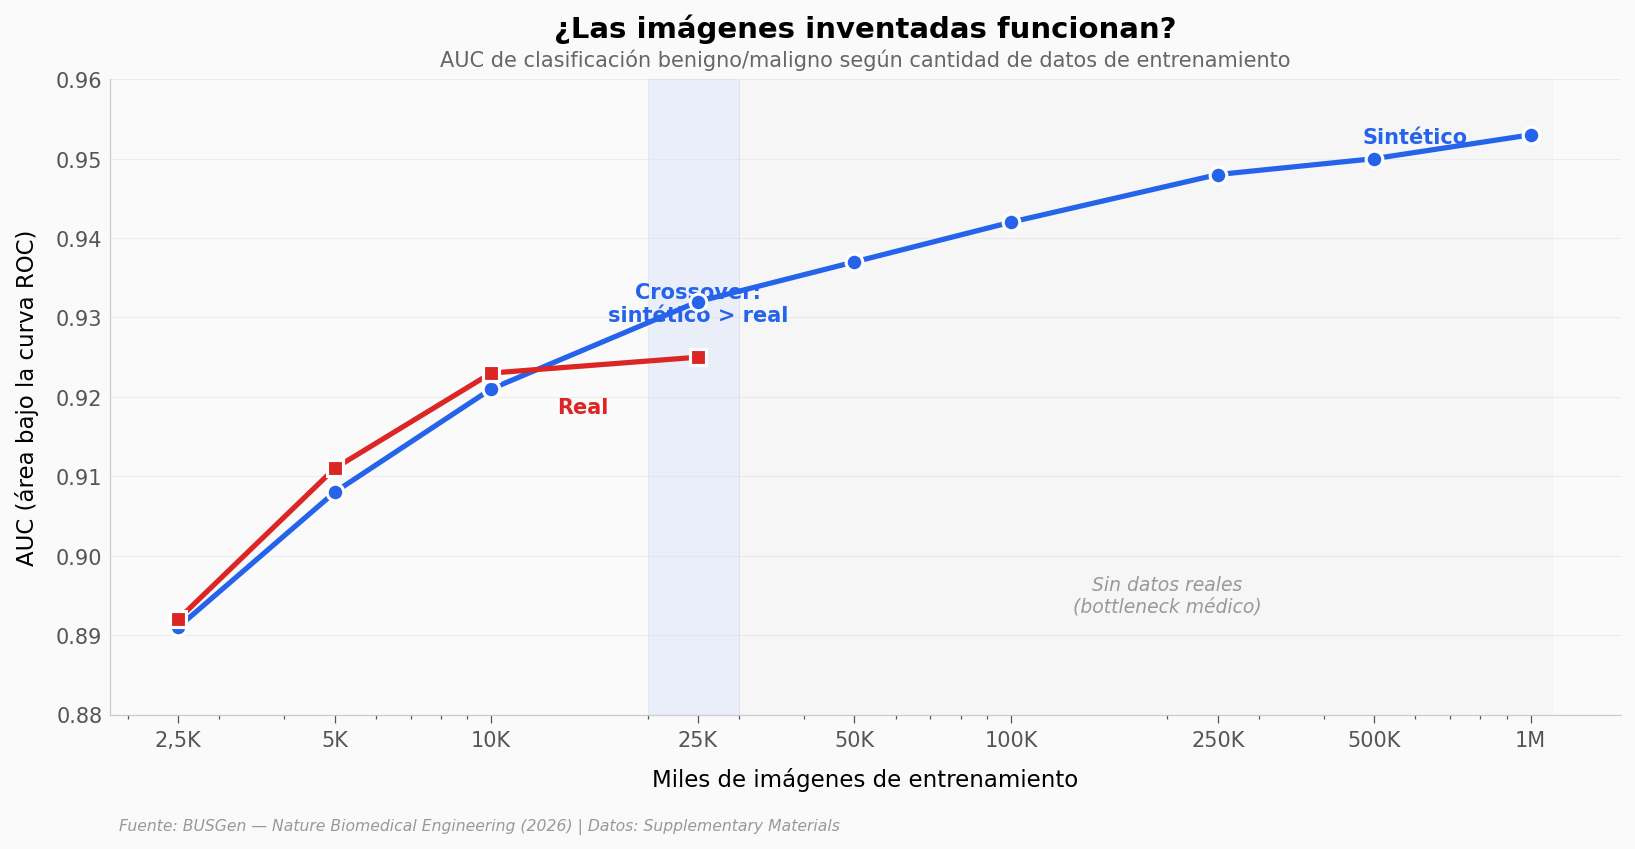

In [2]:
# ── Gráfica hero: Scaling Effect ──
fig, ax = plt.subplots(figsize=(13, 5.5))

# Datos sintéticos (todos los puntos)
gen_mask = scaling['auc_generated'].notna()
ax.plot(scaling.loc[gen_mask, 'scale_raw'] / 1000,
        scaling.loc[gen_mask, 'auc_generated'],
        '-o', color=COLOR_IA, linewidth=2.5, markersize=8,
        markeredgecolor='white', markeredgewidth=1.5, zorder=5,
        label='Datos sintéticos (BUSGen)')

# Datos reales (solo donde hay)
real_mask = scaling['auc_real'].notna() & (scaling['auc_real'] != '')
real_df = scaling[real_mask].copy()
real_df['auc_real'] = real_df['auc_real'].astype(float)
ax.plot(real_df['scale_raw'] / 1000, real_df['auc_real'],
        '-s', color=COLOR_REAL, linewidth=2.5, markersize=8,
        markeredgecolor='white', markeredgewidth=1.5, zorder=5,
        label='Datos reales')

# Zona de crossover
ax.axvspan(20, 30, alpha=0.08, color=COLOR_IA, zorder=0)
ax.annotate('Crossover:\nsintético > real',
            xy=(25, 0.929), fontsize=10, fontweight='bold',
            color=COLOR_IA, ha='center', va='bottom')

# Zona sin datos reales
ax.axvspan(30, 1100, alpha=0.04, color='#999999', zorder=0)
ax.text(200, 0.895, 'Sin datos reales\n(bottleneck médico)',
        fontsize=9, color='#999999', ha='center', va='center', style='italic')

# Inline labels
ax.text(600, 0.952, 'Sintético', fontsize=10, fontweight='bold',
        color=COLOR_IA, ha='center')
ax.text(15, 0.918, 'Real', fontsize=10, fontweight='bold',
        color=COLOR_REAL, ha='center')

ax.set_xscale('log')
ax.set_xlabel('Miles de imágenes de entrenamiento', fontsize=11)
ax.set_ylabel('AUC (área bajo la curva ROC)', fontsize=11)
ax.set_title('¿Las imágenes inventadas funcionan?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'AUC de clasificación benigno/maligno según cantidad de datos de entrenamiento',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xticks([2.5, 5, 10, 25, 50, 100, 250, 500, 1000])
ax.set_xticklabels(['2,5K', '5K', '10K', '25K', '50K', '100K', '250K', '500K', '1M'])
ax.set_ylim(0.880, 0.960)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/scaling_auc.png', dpi=200, bbox_inches='tight')
plt.show()

### ¿Qué vemos?

Hasta 10.000 imágenes, los datos reales ganan por un margen mínimo (AUC 0,923 vs 0,921). Pero a partir de **25.000**, los sintéticos cruzan: AUC 0,932 frente a 0,925.

Y aquí viene lo importante: los datos reales se **agotan**. No hay más ecografías etiquetadas disponibles — es el cuello de botella clásico de la IA médica. Pero los sintéticos no tienen ese límite. BUSGen sigue generando, y a 1 millón de imágenes alcanza un AUC de **0,953**.

> Ese salto de 0,925 → 0,953 (+0,028) **no tiene equivalente** con datos reales — simplemente no hay tantas ecografías etiquetadas disponibles.

## La prueba de fuego: IA vs 9 radiólogos

Generar imágenes realistas es una cosa. ¿Pero el modelo entrenado con ellas puede competir con radiólogos experimentados?

Nueve especialistas evaluaron las mismas ecografías.

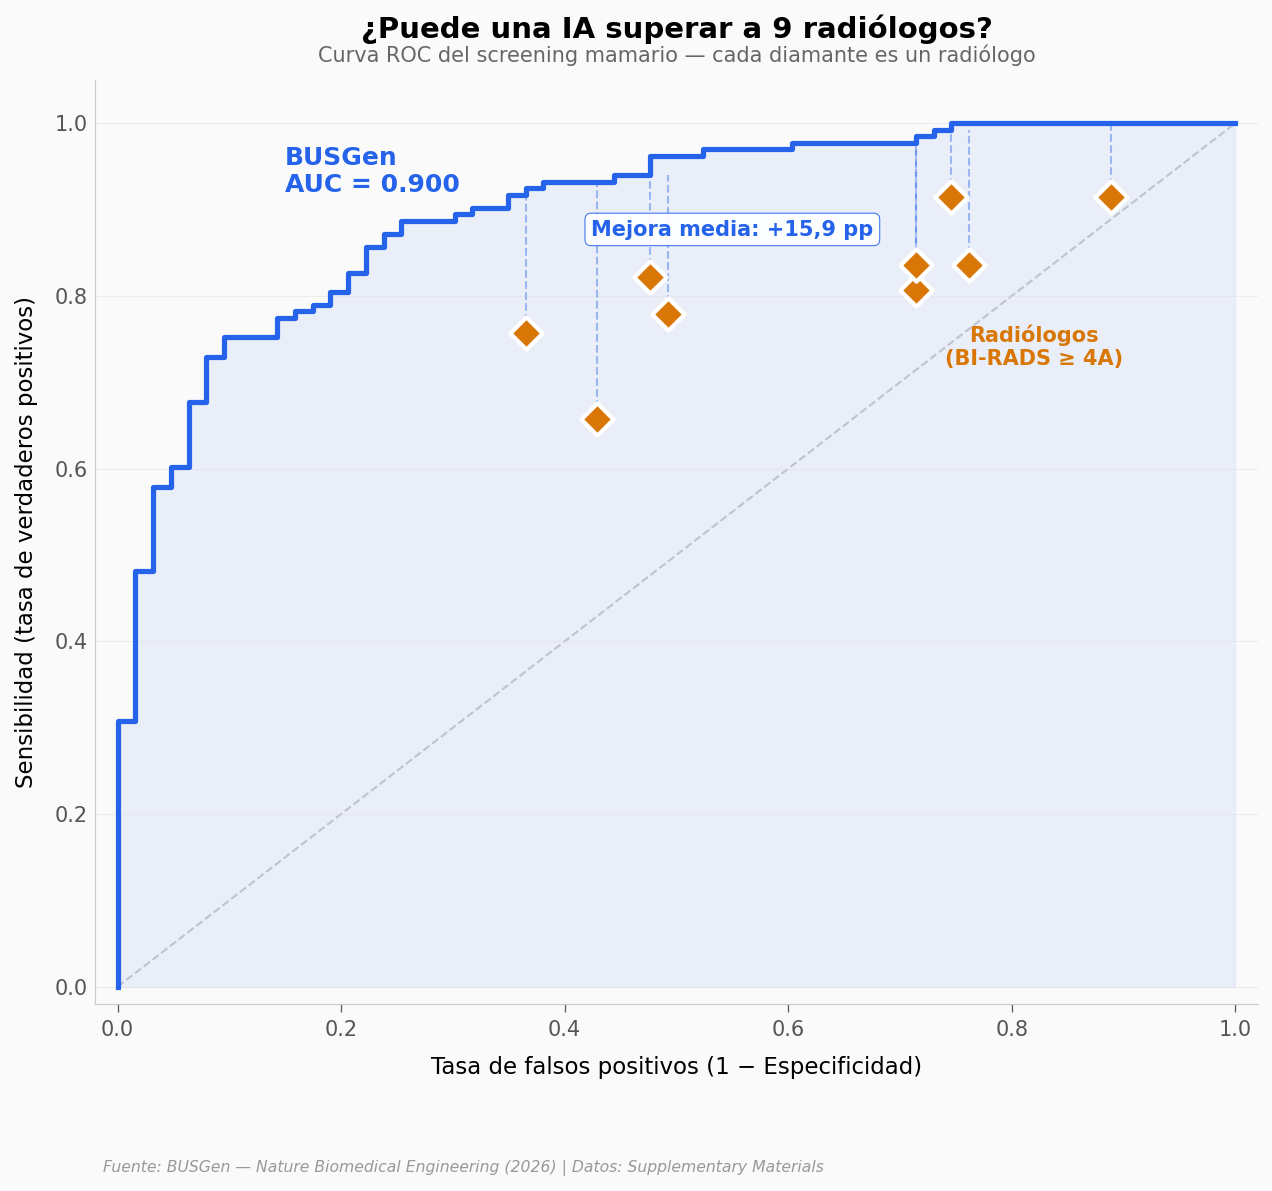

In [3]:
# ── IA vs 9 Radiólogos: Curva ROC (screening) ──
fig, ax = plt.subplots(figsize=(10, 8))

# Curva ROC de la IA
ax.plot(roc_screen['fpr'], roc_screen['tpr'],
        color=COLOR_IA, linewidth=2.5, zorder=4)
ax.fill_between(roc_screen['fpr'], roc_screen['tpr'],
                alpha=0.08, color=COLOR_IA, zorder=1)

# Reader points @ BI-RADS 4A (threshold clínico estándar)
r4a = readers_screen[readers_screen['birads_threshold'] == '4A']
ax.scatter(r4a['fpr'], r4a['sensitivity'],
           color=COLOR_READERS, s=120, zorder=6,
           edgecolors='white', linewidths=2, marker='D')

# Líneas desde cada radiólogo hasta la curva ROC (mejora de sensibilidad)
for _, reader in r4a.iterrows():
    # Encontrar TPR de la IA al mismo FPR
    idx = (roc_screen['fpr'] - reader['fpr']).abs().idxmin()
    ai_tpr = roc_screen.loc[idx, 'tpr']
    ax.plot([reader['fpr'], reader['fpr']],
            [reader['sensitivity'], ai_tpr],
            color=COLOR_IA, linewidth=1, alpha=0.4, linestyle='--', zorder=3)

# Diagonal (clasificador aleatorio)
ax.plot([0, 1], [0, 1], '--', color='#CCCCCC', linewidth=1, zorder=0)

# Inline labels
ax.text(0.15, 0.92, f'BUSGen\nAUC = {AUC_SCREENING:.3f}',
        fontsize=12, fontweight='bold', color=COLOR_IA)
ax.text(0.82, 0.72, 'Radiólogos\n(BI-RADS ≥ 4A)',
        fontsize=10, fontweight='bold', color=COLOR_READERS, ha='center')

# Annotation: average improvement
mean_reader_sens = r4a['sensitivity'].mean()
ax.annotate(f'Mejora media: +15,9 pp',
            xy=(0.55, 0.87), fontsize=10, fontweight='bold',
            color=COLOR_IA, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=COLOR_IA, alpha=0.9))

ax.set_xlabel('Tasa de falsos positivos (1 − Especificidad)', fontsize=11)
ax.set_ylabel('Sensibilidad (tasa de verdaderos positivos)', fontsize=11)
ax.set_title('¿Puede una IA superar a 9 radiólogos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Curva ROC del screening mamario — cada diamante es un radiólogo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/roc_screening.png', dpi=200, bbox_inches='tight')
plt.show()

### La curva lo dice todo

Al mismo nivel de falsos positivos que cada radiólogo, la IA detecta más cánceres. La mejora promedio es de **+15,9 puntos porcentuales** de sensibilidad. El paper reporta +16,5% (p < 0,0001) — la diferencia es por interpolación discreta en nuestra curva.

La diferencia varía entre radiólogos: desde +8,6 pp (los que ya tenían sensibilidad alta, como R1 y R7 con 91,4%) hasta **+27,5 pp** para R6, que tenía la sensibilidad más baja (65,7%).

> Ojo: AUC alto en screening ≠ diagnóstico. La IA estima probabilidad de malignidad — el radiólogo decide si se hace biopsia. Son tareas distintas.

## ¿Y si trabajan juntos?

La pregunta real no es "IA vs humano" sino "IA + humano vs humano solo". Los mismos 9 radiólogos evaluaron ecografías con y sin asistencia de BUSGen.

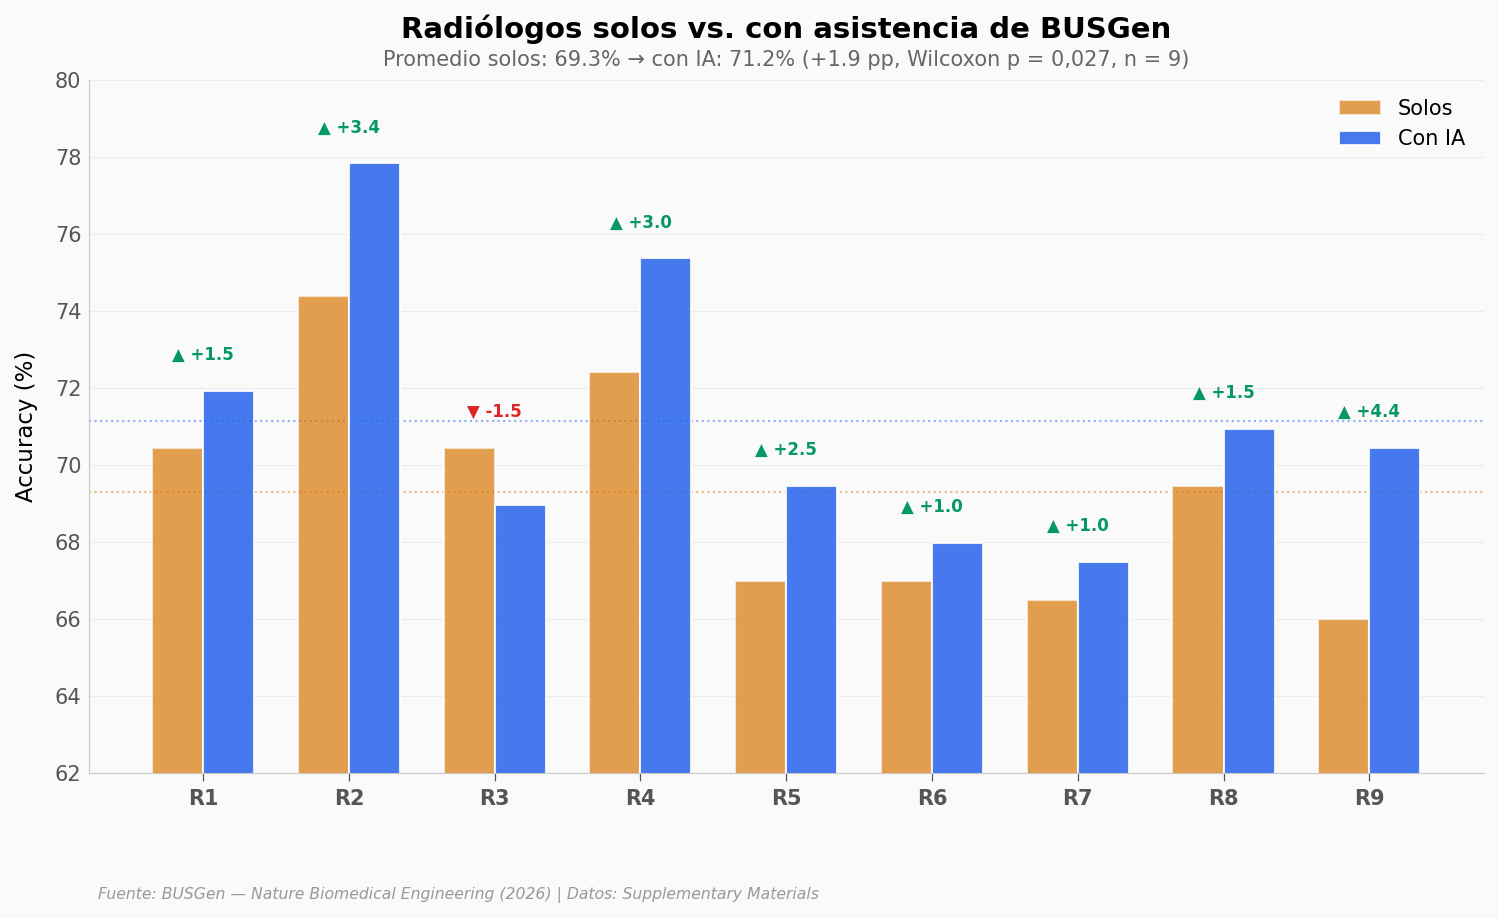

In [4]:
# ── Accuracy: Radiólogos solos vs con IA ──
fig, ax = plt.subplots(figsize=(12, 6))

readers_alone = accuracy[accuracy['stage'] == 'Readers'].sort_values('reader_id')
readers_with_ai = accuracy[accuracy['stage'] == 'Readers with AI-assistance'].sort_values('reader_id')

reader_ids = readers_alone['reader_id'].values
acc_alone = readers_alone['accuracy'].values * 100
acc_ai = readers_with_ai['accuracy'].values * 100

x = np.arange(len(reader_ids))
width = 0.35

bars1 = ax.bar(x - width/2, acc_alone, width, color=COLOR_READERS, alpha=0.7,
               edgecolor='white', linewidth=1, label='Solos', zorder=3)
bars2 = ax.bar(x + width/2, acc_ai, width, color=COLOR_IA, alpha=0.85,
               edgecolor='white', linewidth=1, label='Con IA', zorder=3)

# Flechas de mejora
for i, (a, b) in enumerate(zip(acc_alone, acc_ai)):
    diff = b - a
    color = COLOR_SEC if diff > 0 else COLOR_REAL
    symbol = '▲' if diff > 0 else '▼'
    ax.text(i, max(a, b) + 0.8, f'{symbol} {diff:+.1f}',
            fontsize=8, fontweight='bold', color=color, ha='center')

# Promedios
mean_alone = acc_alone.mean()
mean_ai = acc_ai.mean()
ax.axhline(y=mean_alone, color=COLOR_READERS, linewidth=1, linestyle=':', alpha=0.5)
ax.axhline(y=mean_ai, color=COLOR_IA, linewidth=1, linestyle=':', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(reader_ids, fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_ylim(62, 80)

ax.set_title('Radiólogos solos vs. con asistencia de BUSGen',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02,
        f'Promedio solos: {mean_alone:.1f}% → con IA: {mean_ai:.1f}% (+{mean_ai-mean_alone:.1f} pp, Wilcoxon p = 0,027, n = 9)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/accuracy_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### El efecto es modesto pero consistente

La mejora promedio es de **+1,9 puntos porcentuales** (de 69,3% a 71,2%). ¿Suena poco? Depende de cómo lo mires.

**8 de 9 radiólogos mejoraron** con la IA. Solo R3 bajó marginalmente (−1,5 pp). El efecto es estadísticamente significativo (Wilcoxon signed-rank, p = 0,027, n = 9) y el tamaño del efecto es **grande** (Cohen's d pareado = 1,08). ¿Cómo puede ser "grande" un cambio de 1,9 pp? Porque la variabilidad entre radiólogos es pequeña — todos mejoran de forma consistente, no hay ruido.

El mayor salto fue R9: **+4,4 pp** (de 66,0% a 70,4%).

## ¿Cuánto mejoró cada radiólogo?

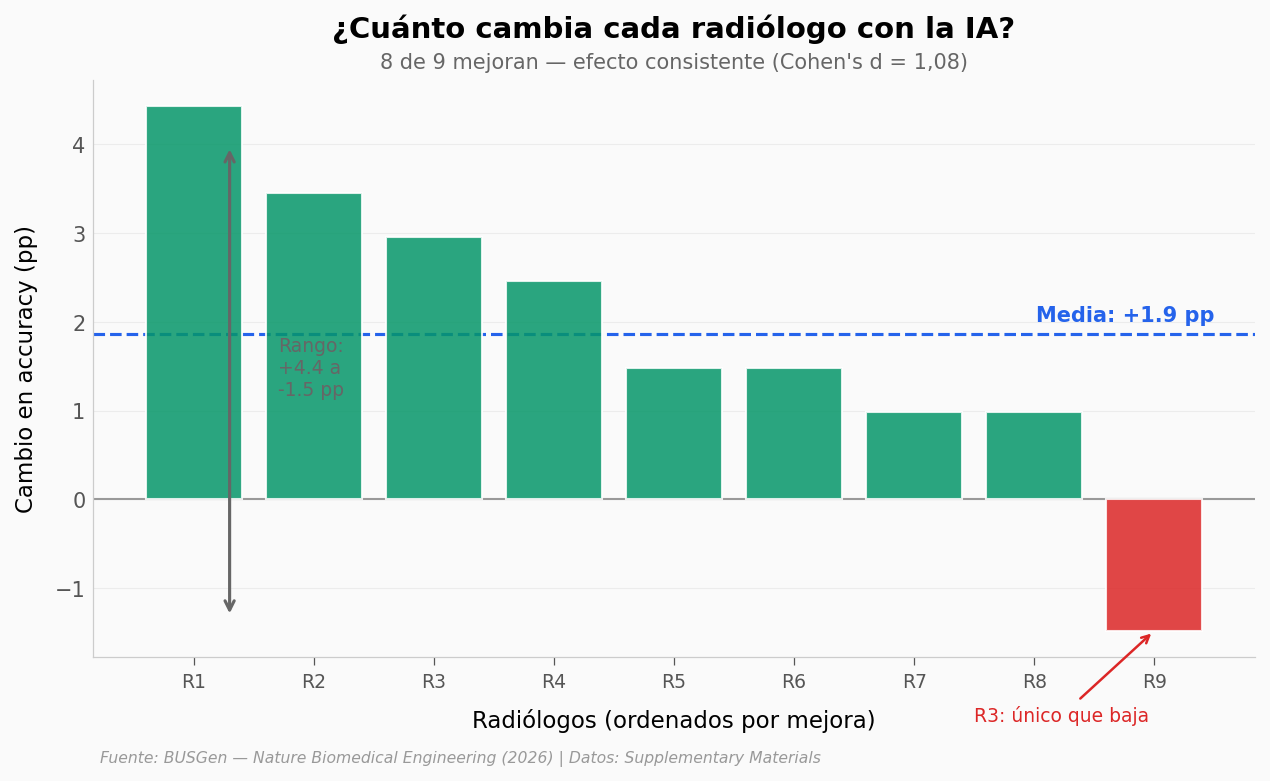

In [5]:
# ── Histograma: distribución de mejoras por radiólogo ──
fig, ax = plt.subplots(figsize=(10, 5))

diffs = (acc_ai - acc_alone)  # ya en porcentaje
colors = [COLOR_SEC if d > 0 else COLOR_REAL for d in diffs]

bars = ax.bar(range(len(diffs)), sorted(diffs, reverse=True),
              color=[COLOR_SEC if d > 0 else COLOR_REAL for d in sorted(diffs, reverse=True)],
              edgecolor='white', linewidth=1, alpha=0.85, zorder=3)

# Línea de cero
ax.axhline(y=0, color='#999999', linewidth=1, zorder=2)

# Media
mean_diff = np.mean(diffs)
ax.axhline(y=mean_diff, color=COLOR_IA, linewidth=1.5, linestyle='--', zorder=2)
ax.text(len(diffs) - 0.5, mean_diff + 0.15,
        f'Media: +{mean_diff:.1f} pp',
        fontsize=10, fontweight='bold', color=COLOR_IA, ha='right')

# Anotación del outlier negativo
ax.annotate('R3: único que baja',
            xy=(len(diffs)-1, sorted(diffs, reverse=True)[-1]),
            xytext=(len(diffs)-2.5, -2.5),
            fontsize=9, color=COLOR_REAL,
            arrowprops=dict(arrowstyle='->', color=COLOR_REAL, lw=1.2))

# Flecha bidireccional
y_max = max(diffs) * 1.15
ax.annotate('', xy=(0.3, max(diffs)*0.9), xytext=(0.3, min(diffs)*0.9),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(0.7, np.mean([max(diffs), min(diffs)]),
        f'Rango:\n{max(diffs):+.1f} a\n{min(diffs):+.1f} pp',
        fontsize=9, color='#666666', va='center')

ax.set_xlabel('Radiólogos (ordenados por mejora)', fontsize=11)
ax.set_ylabel('Cambio en accuracy (pp)', fontsize=11)
ax.set_title('¿Cuánto cambia cada radiólogo con la IA?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '8 de 9 mejoran — efecto consistente (Cohen\'s d = 1,08)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xticks(range(len(diffs)))
ax.set_xticklabels([f'R{i+1}' for i in range(len(diffs))], fontsize=9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mejora_radiologos.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La IA supera a los 9 radiólogos en sensibilidad de screening | ✅ | Al mismo FPR, la IA tiene mayor sensibilidad en los 9 casos. Mejora media: +15,9 pp (paper reporta +16,5%) |
| Los datos sintéticos superan a los reales a partir de 25K | ✅ | AUC sintético 0,932 vs real 0,925 a 25K muestras. Crossover verificado |
| La IA mejora la accuracy de los radiólogos | ✅ | +1,9 pp, Wilcoxon p = 0,027, Cohen's d = 1,08, n = 9. 8/9 mejoran |
| A 1 millón de imágenes sintéticas, AUC = 0,953 | ✅ | Dato directo del supplementary. No hay datos reales a esa escala para comparar |
| BUSGen permite compartir datos de-identificados | ⚠️ | El claim es del abstract. Los supplementary no incluyen datos para verificar este aspecto de privacidad |

> **Limitaciones:**
> - Los datos del supplementary cubren las figuras del paper, no el dataset completo de 3,5 millones de imágenes
> - La mejora de +16,5% en sensibilidad proviene de comparar la curva ROC con los puntos operativos de cada radiólogo — nuestro cálculo da +15,9 pp (diferencia por interpolación discreta)
> - El AUC de 0,90 (screening) estima riesgo, NO diagnostica. Un AUC de 0,90 significa que en el 90% de los pares aleatorios (caso positivo, caso negativo), el modelo asigna mayor probabilidad al positivo
> - Los datos de scaling (>25K) solo tienen AUC para datos sintéticos — no hay benchmark real para validar la tendencia

## Ahora tú

1. **¿Qué pasa con la curva de diagnóstico?** Los CSVs `roc_diagnosis.csv` y `readers_diagnosis.csv` tienen datos de la tarea de diagnóstico (no screening). ¿El AUC es mayor o menor? ¿Los radiólogos están más cerca de la curva?

2. **¿Hay un "techo" en el scaling?** La curva sintética parece aplanarse. ¿Cuál es la ganancia marginal entre 500K y 1M? ¿Vale la pena generar el doble de imágenes por esa mejora?

3. **¿R3 es un caso atípico?** Es el único radiólogo que empeora con la IA. ¿Qué accuracy tenía solo? ¿Era ya el mejor del grupo?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿Hay un techo en el scaling?

gen_data = scaling[scaling['auc_generated'].notna()].copy()
gen_data['auc_generated'] = gen_data['auc_generated'].astype(float)

# Ganancia marginal entre escalas consecutivas
gen_data['ganancia'] = gen_data['auc_generated'].diff()
gen_data['ganancia_pct'] = (gen_data['ganancia'] / gen_data['auc_generated'].shift(1)) * 100

print("¿Rendimientos decrecientes?")
print(f"{'Escala':>10} {'AUC':>8} {'Ganancia':>10} {'% relativo':>12}")
print("-" * 45)
for _, row in gen_data.iterrows():
    g = f"+{row['ganancia']:.3f}" if pd.notna(row['ganancia']) else "—"
    p = f"+{row['ganancia_pct']:.2f}%" if pd.notna(row['ganancia_pct']) else "—"
    print(f"{row['scale_k']:>8}K {row['auc_generated']:>8.3f} {g:>10} {p:>12}")

print(f"\nGanancia 500K → 1M: +{gen_data.iloc[-1]['ganancia']:.3f} (AUC)")
print(f"Ganancia 2.5K → 25K: +{gen_data.iloc[3]['auc_generated'] - gen_data.iloc[0]['auc_generated']:.3f} (AUC)")
print(f"\nDuplicar de 500K a 1M da {gen_data.iloc[-1]['ganancia']:.3f} de AUC.")
print(f"Las primeras 25K imágenes dieron {gen_data.iloc[3]['auc_generated'] - gen_data.iloc[0]['auc_generated']:.3f}.")
print("Los rendimientos son decrecientes, pero cada décima cuenta en oncología.")

¿Rendimientos decrecientes?
    Escala      AUC   Ganancia   % relativo
---------------------------------------------
     2.5K    0.891          —            —
     5.0K    0.908     +0.017       +1.91%
    10.0K    0.921     +0.013       +1.43%
    25.0K    0.932     +0.011       +1.19%
    50.0K    0.937     +0.005       +0.54%
   100.0K    0.942     +0.005       +0.53%
   250.0K    0.948     +0.006       +0.64%
   500.0K    0.950     +0.002       +0.21%
  1000.0K    0.953     +0.003       +0.32%

Ganancia 500K → 1M: +0.003 (AUC)
Ganancia 2.5K → 25K: +0.041 (AUC)

Duplicar de 500K a 1M da 0.003 de AUC.
Las primeras 25K imágenes dieron 0.041.
Los rendimientos son decrecientes, pero cada décima cuenta en oncología.


---

## Créditos

- **Paper:** A foundation generative model for breast ultrasound image analysis
- **DOI:** [10.1038/s41551-026-01639-1](https://doi.org/10.1038/s41551-026-01639-1)
- **Journal:** Nature Biomedical Engineering
- **Datos:** Supplementary Materials (Source Data)
- **Licencia datos:** Creative Commons (Springer Nature)

---
*Notebook generado para [El Lab de Ciencia a Mordiscos](https://cienciaamordiscos.com) — reproducibilidad primero.*